# **P&L Attribution — Carry, Rolldown, Risk, and PCA-Based Curve Attribution**

This notebook walks the full attribution stack built in Project 2 end to end,
on the real bootstrapped GBP SONIA curve(s) and a single 2-swap portfolio used
throughout: a **10Y receiver** (£1m notional, 4.5% fixed) and a **5Y payer**
(£500k notional, 3.8% fixed).

## Scope and known limitations

- **SONIA proxy**: `sonia_rate` uses `curve.zero_rate(1.0)` as a stand-in
  for an observed overnight fixing, which this project doesn't have.
- **PC truncation**: `curve_factor_pnl`/`residual` split depends on
  `n_components` (see Section 5) — residual is not "error," it's
  whatever the chosen number of components doesn't explain.
- **Curve extended to T=0** (Project 1 fix): enables valuing swaps
  inside their final year via the D(0)=1 identity — see Project 1's
  CLAUDE.md for detail.
- **Naive dates, no business-day convention** (inherited from Project 1,
  M10, still deferred).

## 1. Setup

Build the 2-swap portfolio used throughout this notebook, and load both
curve sources this project works with:

- the **static** BoE snapshot curve (Project 1's `boe_ois_quotes.csv`,
  bootstrapped once) — used for inception valuation, carry/rolldown/time
  decay, and risk (Sections 2-3), matching this project's test suite exactly.
- the **historical daily archive** (`boe_historical_curves.csv`) — used
  for PCA and the two-date attribution demo (Sections 4-5).

**SONIA proxy limitation**: this project has no observed overnight SONIA
fixing — only the bootstrapped curve. `carry()`/`total_carry()` require a
`sonia_rate` to be supplied by the caller, and throughout this notebook
(and the test suite) that's approximated as `curve.zero_rate(1.0)`, the
curve's own 1Y zero rate. This is a stand-in, not a real fixing — and
because it's re-derived from whichever curve is in scope, Section 5 below
recomputes it from that section's own (historical, dated) curve rather
than reusing this section's static-curve value.

In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.attribution import _curve_for_date, attribute_pnl
from src.curve_pca import TENORS, build_zero_rate_matrix, daily_changes, run_pca
from src.portfolio import Portfolio, _build_curve_from_boe_data
from src.swap import Curve, Swap

%matplotlib inline

# Same validated palette Project 1's notebook uses (blue/red = categorical
# slots 1/6; primary/secondary/muted/grid/baseline = chart chrome & ink).
# Extended here with two more categorical slots (aqua, yellow) for PC2/PC3,
# and the reserved status pair (good/critical) for positive/negative P&L --
# deliberately distinct from the categorical slots per the palette's own rule.
COLOR_PRIMARY = "#0b0b0b"
COLOR_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"

COLOR_BLUE = "#2a78d6"      # slot 1 -- PC1 / level
COLOR_AQUA = "#1baf7a"      # slot 2 -- PC2 / slope
COLOR_YELLOW = "#eda100"    # slot 3 -- PC3 / curvature
COLOR_RED = "#e34948"       # slot 6 -- singled-out highlight (the 5Y bar)

COLOR_GOOD = "#0ca30c"      # status: positive P&L
COLOR_CRITICAL = "#d03b3b"  # status: negative P&L / threshold breach


def _style_axes(ax):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(COLOR_BASELINE)
    ax.tick_params(colors=COLOR_SECONDARY, labelsize=9)
    ax.yaxis.grid(True, color=COLOR_GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)


TRADE_DATE = date(2025, 1, 1)

swap_a = Swap(TRADE_DATE, TRADE_DATE + timedelta(days=365 * 10), 1_000_000, 0.045, 'receiver')
swap_b = Swap(TRADE_DATE, TRADE_DATE + timedelta(days=365 * 5), 500_000, 0.038, 'payer')
portfolio = Portfolio([swap_a, swap_b])

curve = _build_curve_from_boe_data()
sonia_rate = curve.zero_rate(1.0)
tenors = [float(t) for t in TENORS]

print(f"Portfolio: {len(portfolio.swaps)} swaps")
print(f"  Swap A: 10Y receiver, \u00a3{swap_a.notional:,.0f} @ {swap_a.fixed_rate:.2%}")
print(f"  Swap B: 5Y payer,     \u00a3{swap_b.notional:,.0f} @ {swap_b.fixed_rate:.2%}")
print(f"sonia_rate proxy (curve.zero_rate(1.0)): {sonia_rate:.4%}")

Portfolio: 2 swaps
  Swap A: 10Y receiver, £1,000,000 @ 4.50%
  Swap B: 5Y payer,     £500,000 @ 3.80%
sonia_rate proxy (curve.zero_rate(1.0)): 3.8351%


## 2. Valuation & Time Decay

Value the portfolio at inception, then roll forward 30 days on the *same*
static curve to see carry and rolldown fall out of the swap-level
`total_time_decay` split — `carry` is the pure coupon-economics piece
(fixed rate vs. the SONIA proxy), and `rolldown` is defined as whatever's
left over (`total_time_decay - carry`), not computed independently. The
reconciliation below (`carry + rolldown == total_time_decay`) is shown
explicitly here, not just asserted in a test.

In [2]:
days = 30

pv_inception = portfolio.present_value(curve, TRADE_DATE)
carry = portfolio.total_carry(sonia_rate, days)
rolldown = portfolio.total_rolldown(curve, TRADE_DATE, sonia_rate, days)
total_time_decay = portfolio.total_time_decay(curve, TRADE_DATE, days)

print(f"Portfolio PV at inception: \u00a3{pv_inception:,.2f}\n")

decay_table = pd.DataFrame({
    "\u00a3": {
        "Carry (30d)": carry,
        "Rolldown (30d)": rolldown,
        "Carry + Rolldown": carry + rolldown,
        "Total time decay (30d)": total_time_decay,
    }
})
display(decay_table.style.format("{:+,.2f}"))

print(f"\nReconciliation: carry + rolldown = {carry + rolldown:,.6f}")
print(f"                total_time_decay = {total_time_decay:,.6f}")
print(f"                difference       = {abs((carry + rolldown) - total_time_decay):.2e}  (exact, by construction)")

Portfolio PV at inception: £18,941.81



,£
Carry (30d),+532.05
Rolldown (30d),"+1,730.76"
Carry + Rolldown,"+2,262.81"
Total time decay (30d),"+2,262.81"



Reconciliation: carry + rolldown = 2,262.813612
                total_time_decay = 2,262.813612
                difference       = 0.00e+00  (exact, by construction)


## 3. Risk — DV01 and Key-Rate Duration

DV01 is a single-number, parallel-shock sensitivity: base-minus-shocked,
so positive means the position loses value when rates rise (bond-holder
convention). Key-rate duration (KRD) breaks that single number down by
tenor — bumping one pillar at a time and summing across swaps — and the
two must reconcile: `sum(KRD)` across all 10 tenors should equal the
portfolio's parallel DV01 exactly, since a parallel shock is nothing more
than every key rate moving together.

In [3]:
dv01_table = pd.DataFrame({
    "DV01 (\u00a3 per 1bp)": {
        "Swap A (10Y receiver)": swap_a.dv01(curve, TRADE_DATE),
        "Swap B (5Y payer)": swap_b.dv01(curve, TRADE_DATE),
        "Portfolio (sum)": portfolio.total_dv01(curve, TRADE_DATE),
    }
})
display(dv01_table.style.format("{:+,.2f}"))

krd = portfolio.key_rate_durations(curve, TRADE_DATE)
krd_df = pd.DataFrame(
    {"KRD (\u00a3 per 1bp)": [krd[t] for t in sorted(krd)]},
    index=[f"{int(t)}Y" for t in sorted(krd)],
)
display(krd_df.style.format("{:+,.2f}"))

portfolio_dv01 = portfolio.total_dv01(curve, TRADE_DATE)
print(f"sum(KRD)            = \u00a3{sum(krd.values()):,.2f}")
print(f"portfolio.total_dv01 = \u00a3{portfolio_dv01:,.2f}")
print(f"difference           = {abs(sum(krd.values()) - portfolio_dv01):.2e}  (exact, by construction)")

,DV01 (£ per 1bp)
Swap A (10Y receiver),+837.79
Swap B (5Y payer),-229.82
Portfolio (sum),+607.97


,KRD (£ per 1bp)
1Y,+2.50
2Y,+4.81
3Y,+6.94
4Y,+8.89
5Y,-194.45
6Y,+21.23
7Y,+23.69
8Y,+25.85
9Y,+27.72
10Y,+680.79


sum(KRD)            = £607.97
portfolio.total_dv01 = £607.97
difference           = 3.64e-10  (exact, by construction)


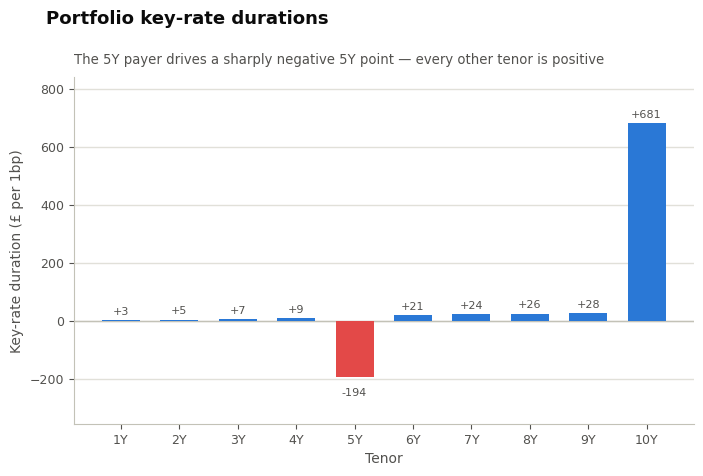

In [4]:
tenors_sorted = sorted(krd)
bar_colors = [COLOR_RED if t == 5.0 else COLOR_BLUE for t in tenors_sorted]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([f"{int(t)}Y" for t in tenors_sorted], [krd[t] for t in tenors_sorted],
              color=bar_colors, width=0.65, zorder=3)
ax.axhline(0, color=COLOR_BASELINE, linewidth=1, zorder=2)

for bar, t in zip(bars, tenors_sorted):
    value = krd[t]
    ax.annotate(
        f"{value:+,.0f}", xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 4 if value >= 0 else -13), textcoords="offset points",
        ha="center", fontsize=8, color=COLOR_SECONDARY,
    )

ax.set_xlabel("Tenor", color=COLOR_SECONDARY, fontsize=10)
ax.set_ylabel("Key-rate duration (\u00a3 per 1bp)", color=COLOR_SECONDARY, fontsize=10)
_style_axes(ax)

fig.suptitle("Portfolio key-rate durations", x=0.09, y=1.03, ha="left",
             fontsize=13, fontweight="bold", color=COLOR_PRIMARY)
ax.set_title("The 5Y payer drives a sharply negative 5Y point \u2014 every other tenor is positive",
             fontsize=9.5, color=COLOR_SECONDARY, loc="left", pad=10)

ymin, ymax = ax.get_ylim()
pad = (ymax - ymin) * 0.12
ax.set_ylim(ymin - pad, ymax + pad)

plt.show()

## 4. PCA on Historical Curve Moves

Bootstrap a `Curve` for every date in the ~2-year daily archive, take
day-over-day changes in the zero-rate curve, and eigendecompose their
covariance matrix (see `src/curve_pca.py`, M7). The classic
Litterman-Scheinkman shapes fall out directly from the real data: PC1 is
a **level** shift (all 10 weights the same sign), PC2 is a **slope**
tilt (one sign change), PC3 is **curvature** (two sign changes).

In [5]:
dates, zero_rate_matrix = build_zero_rate_matrix(csv_path=REPO_ROOT / "data/processed/boe_historical_curves.csv")
changes = daily_changes(zero_rate_matrix)
eigenvalues, eigenvectors = run_pca(changes)
explained_variance_ratio = eigenvalues / eigenvalues.sum()

print(f"{len(dates)} dates ({dates[0]} to {dates[-1]}), {changes.shape[0]} daily changes\n")

pc_table = pd.DataFrame(
    eigenvectors[:, :3].T,
    index=["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"],
    columns=[f"{t}Y" for t in TENORS],
)
pc_table.insert(0, "Explained Variance", explained_variance_ratio[:3])

display(
    pc_table.style.format({"Explained Variance": "{:.2%}", **{f"{t}Y": "{:+.3f}" for t in TENORS}})
)

506 dates (2024-07-01 to 2026-06-30), 505 daily changes



,Explained Variance,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y
PC1 (level),92.87%,-0.232,-0.328,-0.348,-0.342,-0.332,-0.323,-0.317,-0.312,-0.308,-0.305
PC2 (slope),6.32%,-0.459,-0.474,-0.328,-0.153,-0.001,+0.119,+0.213,+0.289,+0.353,+0.407
PC3 (curvature),0.58%,+0.761,+0.024,-0.371,-0.364,-0.220,-0.078,+0.031,+0.111,+0.174,+0.227


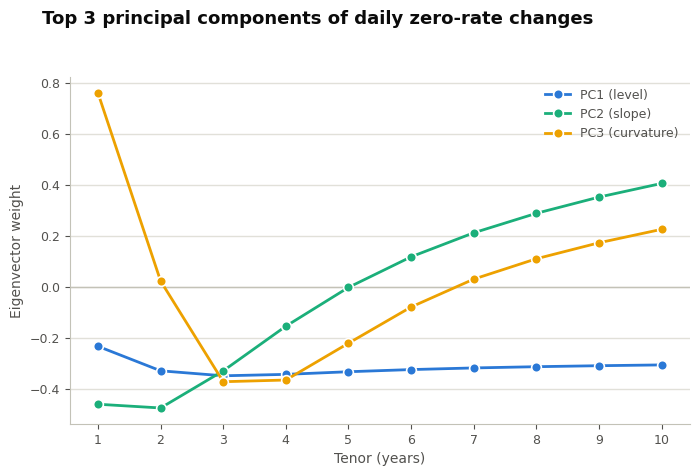

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pc_colors = [COLOR_BLUE, COLOR_AQUA, COLOR_YELLOW]
pc_labels = ["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]

for i in range(3):
    ax.plot(
        TENORS, eigenvectors[:, i], color=pc_colors[i], linewidth=2, marker="o", markersize=7,
        markerfacecolor=pc_colors[i], markeredgecolor="white", markeredgewidth=1.2,
        label=pc_labels[i], zorder=3,
    )
ax.axhline(0, color=COLOR_BASELINE, linewidth=1, zorder=2)
ax.set_xlabel("Tenor (years)", color=COLOR_SECONDARY, fontsize=10)
ax.set_ylabel("Eigenvector weight", color=COLOR_SECONDARY, fontsize=10)
ax.set_xticks(TENORS)
_style_axes(ax)

fig.suptitle("Top 3 principal components of daily zero-rate changes", x=0.09, y=1.03, ha="left",
             fontsize=13, fontweight="bold", color=COLOR_PRIMARY)
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=COLOR_SECONDARY)

plt.show()

## 5. Full Attribution — the Capstone Result

Run `attribute_pnl` on a real one-month window from the historical archive
(2025-06-02 \u2192 2025-07-02), decomposing the portfolio's total P&L into
carry, rolldown, a PCA-reconstructed curve-factor move, and whatever's left
over as residual. Run it twice — `n_components=3` and `n_components=4` —
side by side, so the residual shrinkage is directly visible in one place.
This is the finding worth highlighting: **not** that the numbers reconcile
(they always do, by construction — see the master reconciliation test),
but *how much* the residual depends on how many principal components you
keep.

(Note: `sonia_rate` here is re-derived from `curve_a`, the historical
curve dated 2025-06-02 — not Section 1's static-snapshot `sonia_rate` —
since it's meant to approximate the fixing at the *start* of this specific
attribution window, per the SONIA-proxy limitation noted above.)

In [7]:
date_a, date_b = date(2025, 6, 2), date(2025, 7, 2)
curve_a = _curve_for_date(date_a)
curve_b = _curve_for_date(date_b)
sonia_rate_hist = curve_a.zero_rate(1.0)

result_3 = attribute_pnl(portfolio, curve_a, date_a, curve_b, date_b, sonia_rate_hist, eigenvectors, tenors, n_components=3)
result_4 = attribute_pnl(portfolio, curve_a, date_a, curve_b, date_b, sonia_rate_hist, eigenvectors, tenors, n_components=4)

keys = ["carry", "rolldown", "curve_factor_pnl", "residual", "total_pnl", "reconciled_sum"]
comparison = pd.DataFrame(
    {"n_components=3": [result_3[k] for k in keys], "n_components=4": [result_4[k] for k in keys]},
    index=keys,
)

styled = comparison.style.format("{:+,.2f}").set_properties(
    subset=pd.IndexSlice[["residual"], :], **{"font-weight": "bold", "background-color": "#fff3cd"}
)
display(styled)

print(f"\nResidual: \u00a3{result_3['residual']:,.2f} (n=3)  ->  \u00a3{result_4['residual']:,.2f} (n=4)")
print(f"That's a {abs(result_3['residual'] / result_4['residual']):.1f}x reduction from adding just one more component.")

/Users/emmanueladeleye/Documents/Quants Projects/gbp-sonia-curve-construction/project-2-pnl-attribution/src/attribution.py:68: UserWarning: residual is 11.6% of curve_factor_pnl (residual=-517.44, curve_factor_pnl=4455.95) for 2025-06-02 -> 2025-07-02, above the ~5% expected given PC1-3's typical explained variance.
  warnings.warn(


,n_components=3,n_components=4
carry,+509.97,+509.97
rolldown,"+1,794.00","+1,794.00"
curve_factor_pnl,"+4,455.95","+3,900.48"
residual,-517.44,+38.02
total_pnl,"+6,242.47","+6,242.47"
reconciled_sum,"+6,242.47","+6,242.47"



Residual: £-517.44 (n=3)  ->  £38.02 (n=4)
That's a 13.6x reduction from adding just one more component.


## Why does the residual shrink from -517.44 to +38.02 when adding a 4th component?

Key-rate duration (Section 3) shows this portfolio carries a sharply
negative sensitivity concentrated at the 5Y point (-194.45), driven
entirely by the 5Y payer swap — every other tenor is positive. PC1-3
(level, slope, curvature) only capture the three broadest, most global
shapes a curve typically moves in; they have no mechanism to represent
a real move that happens to wiggle specifically around one pillar.
A portfolio with concentrated single-tenor risk is exactly the case
where PC1-3 truncation shows up larger than the ~1% typical for a more
evenly-spread book. Adding PC4 captures that specific shape, and the
residual drops roughly 13x — direct, testable evidence for this
explanation, not just a plausible story.

## 8. How does the portfolio perform under Project 1's 10 stress scenarios?

Project 1's `src/scenarios.py` provides 3 shock-generating functions
(`apply_parametric_shock`, `apply_wing_anchored_twist`, `apply_butterfly_shock`),
and its own notebook builds 10 named scenarios from them (parallel shifts,
bear/bull flattener/steepener, 2s10s twists, a butterfly). Those exact 10
configurations are reused here unchanged, applied to the base curve, and
diffed against the portfolio's base PV — what does each one actually do to
*this* portfolio's P&L, not just to the curve's shape?

In [8]:
import importlib.util

_SCENARIOS_PATH = REPO_ROOT.parent / "project-1-curve-construction" / "src" / "scenarios.py"
_scenarios_spec = importlib.util.spec_from_file_location("project1_scenarios_notebook", _SCENARIOS_PATH)
_scenarios_module = importlib.util.module_from_spec(_scenarios_spec)
_scenarios_spec.loader.exec_module(_scenarios_module)
apply_parametric_shock = _scenarios_module.apply_parametric_shock
apply_wing_anchored_twist = _scenarios_module.apply_wing_anchored_twist
apply_butterfly_shock = _scenarios_module.apply_butterfly_shock

# The same 10 scenarios as Project 1's own notebook (notebooks/03_scenario_engine.ipynb),
# reused unchanged -- only the target (this portfolio's PV, not curve shape) is new.
scenarios = [
    ("+25bp parallel shift", lambda c: apply_parametric_shock(c, level_shift=0.0025, slope_shift=0.0, pivot_tenor=5.0)),
    ("-25bp parallel shift", lambda c: apply_parametric_shock(c, level_shift=-0.0025, slope_shift=0.0, pivot_tenor=5.0)),
    ("+100bp stress shock", lambda c: apply_parametric_shock(c, level_shift=0.01, slope_shift=0.0, pivot_tenor=5.0)),
    ("Bear flattener", lambda c: apply_parametric_shock(c, level_shift=0.005, slope_shift=-0.003, pivot_tenor=5.0)),
    ("Bear steepener", lambda c: apply_parametric_shock(c, level_shift=0.005, slope_shift=0.003, pivot_tenor=5.0)),
    ("Bull flattener", lambda c: apply_parametric_shock(c, level_shift=-0.005, slope_shift=-0.003, pivot_tenor=5.0)),
    ("Bull steepener", lambda c: apply_parametric_shock(c, level_shift=-0.005, slope_shift=0.003, pivot_tenor=5.0)),
    ("2s10s steepener", lambda c: apply_wing_anchored_twist(c, wing_short=2.0, wing_long=10.0, shock_short=-0.0025, shock_long=0.0025)),
    ("2s10s flattener", lambda c: apply_wing_anchored_twist(c, wing_short=2.0, wing_long=10.0, shock_short=0.0025, shock_long=-0.0025)),
    ("Butterfly/curvature", lambda c: apply_butterfly_shock(c, wing_short=2.0, belly=5.0, wing_long=10.0, wing_shock=-0.0025, belly_shock=0.0025)),
]

base_pv = portfolio.present_value(curve, TRADE_DATE)
scenario_pnl = {}
for name, shock_fn in scenarios:
    shocked_curve = shock_fn(curve)
    scenario_pnl[name] = portfolio.present_value(shocked_curve, TRADE_DATE) - base_pv

scenario_order = sorted(scenario_pnl, key=lambda name: abs(scenario_pnl[name]))

scenario_table = pd.DataFrame({"P&L (\u00a3)": [scenario_pnl[name] for name in scenario_order]}, index=scenario_order)
display(scenario_table.style.format("{:+,.2f}"))

,P&L (£)
Bear flattener,"-8,720.96"
Bull steepener,"+8,864.18"
+25bp parallel shift,"-15,001.34"
-25bp parallel shift,"+15,417.44"
2s10s steepener,"-18,594.89"
2s10s flattener,"+19,031.53"
Butterfly/curvature,"+22,355.32"
Bear steepener,"-49,866.14"
Bull flattener,"+54,330.55"
+100bp stress shock,"-57,614.40"


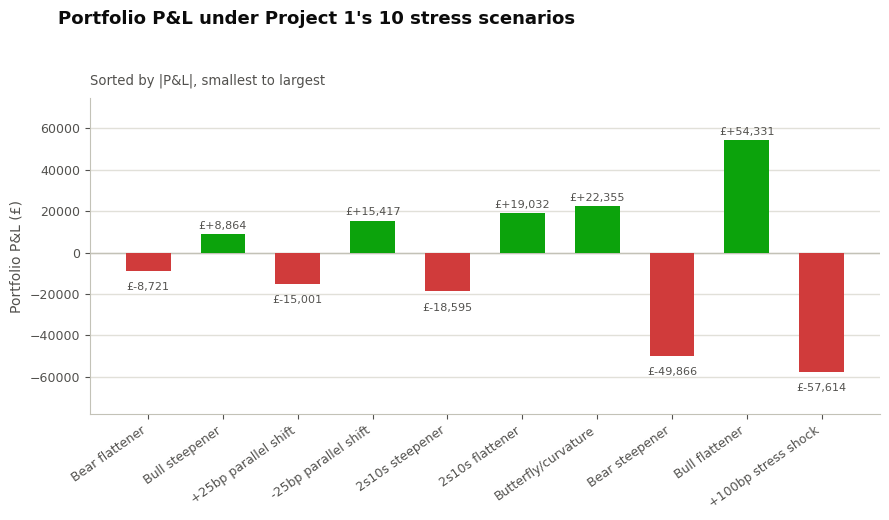

In [9]:
values = [scenario_pnl[name] for name in scenario_order]
bar_colors = [COLOR_GOOD if v >= 0 else COLOR_CRITICAL for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(scenario_order, values, color=bar_colors, width=0.6, zorder=3)
ax.axhline(0, color=COLOR_BASELINE, linewidth=1, zorder=2)

for bar, v in zip(bars, values):
    ax.annotate(
        f"\u00a3{v:+,.0f}", xy=(bar.get_x() + bar.get_width() / 2, v),
        xytext=(0, 4 if v >= 0 else -14), textcoords="offset points",
        ha="center", fontsize=8, color=COLOR_SECONDARY,
    )

ax.set_xticks(range(len(scenario_order)))
ax.set_xticklabels(scenario_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Portfolio P&L (\u00a3)", color=COLOR_SECONDARY, fontsize=10)
_style_axes(ax)

fig.suptitle("Portfolio P&L under Project 1's 10 stress scenarios", x=0.07, y=1.03, ha="left",
             fontsize=13, fontweight="bold", color=COLOR_PRIMARY)
ax.set_title("Sorted by |P&L|, smallest to largest", fontsize=9.5, color=COLOR_SECONDARY, loc="left", pad=10)

ymin, ymax = ax.get_ylim()
pad = (ymax - ymin) * 0.12
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

### Finding

The largest moves are the pure level shocks, as expected from the portfolio's
dominant net DV01 (+£607.97/bp, Section 3): **+100bp stress shock** is the
single worst outcome (-£57,614.40) and **Bull flattener** the best
(+£54,330.55). Every scenario that raises rates loses money and every one
that lowers them gains — consistent with a portfolio that is net long
duration overall (driven by the 10Y receiver's dominant KRD), despite being
short the 5Y point specifically. The two *smallest*-magnitude scenarios are
the two where the twist most directly offsets the level move for this
particular book — **Bear flattener** (-£8,720.96) and **Bull steepener**
(+£8,864.18) — both level+twist combos where the ±30bp slope component
partially cancels the level component's effect on the 10Y-heavy long side.

## 9. Which principal component — level, slope, or curvature — actually drives the June→July `curve_factor_pnl`?

Section 5's `curve_factor_pnl` (n=3, £4,455.95) is the *combined* effect of
reconstructing the observed curve move from PC1+PC2+PC3 together. What's each
component's own **marginal** contribution — not three overlapping cumulative
totals, but the incremental effect of adding PC1, then PC2, then PC3 one at a
time?

In [10]:
from math import exp

from src.attribution import project_onto_pcs, reconstruct_pc_shock


def _shocked_curve_for_n(n_components):
    shock = reconstruct_pc_shock(scores, eigenvectors, tenors, n_components=n_components)
    return Curve({T: exp(-(curve_a.zero_rate(T) + shock[T]) * T) for T in tenors})


real_delta_z = {T: curve_b.zero_rate(T) - curve_a.zero_rate(T) for T in tenors}
scores = project_onto_pcs(real_delta_z, tenors, eigenvectors)

pv_a_at_b = portfolio.present_value(curve_a, date_b)
pv_pc1 = portfolio.present_value(_shocked_curve_for_n(1), date_b)
pv_pc12 = portfolio.present_value(_shocked_curve_for_n(2), date_b)
pv_pc123 = portfolio.present_value(_shocked_curve_for_n(3), date_b)

level_contribution = pv_pc1 - pv_a_at_b
slope_contribution = pv_pc12 - pv_pc1
curvature_contribution = pv_pc123 - pv_pc12
marginal_sum = level_contribution + slope_contribution + curvature_contribution

factor_table = pd.DataFrame(
    {"Marginal P&L (\u00a3)": [level_contribution, slope_contribution, curvature_contribution, marginal_sum]},
    index=["Level (PC1)", "Slope (PC2)", "Curvature (PC3)", "Sum"],
)
display(factor_table.style.format("{:+,.2f}"))

print(f"curve_factor_pnl (n=3, from Section 5) = \u00a3{result_3['curve_factor_pnl']:,.2f}")
print(f"sum of marginal contributions          = \u00a3{marginal_sum:,.2f}  (exact match, by construction)")

,Marginal P&L (£)
Level (PC1),"+7,296.66"
Slope (PC2),"-3,216.74"
Curvature (PC3),+376.03
Sum,"+4,455.95"


curve_factor_pnl (n=3, from Section 5) = £4,455.95
sum of marginal contributions          = £4,455.95  (exact match, by construction)


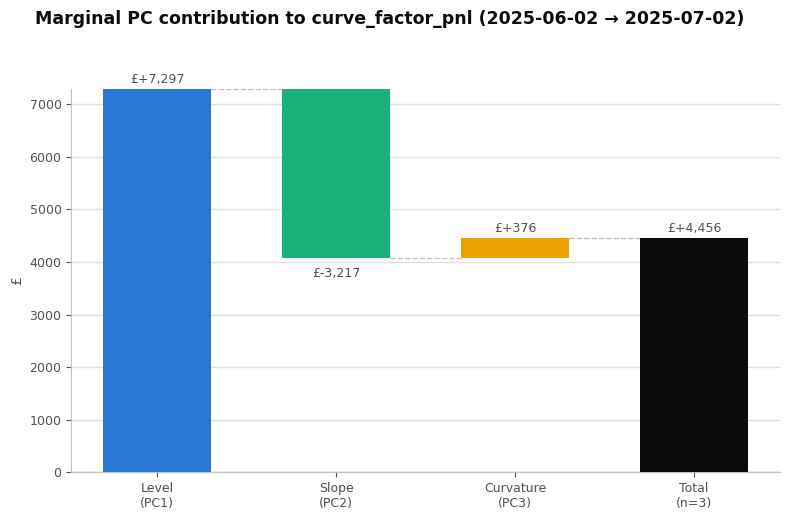

In [11]:
labels = ["Level\n(PC1)", "Slope\n(PC2)", "Curvature\n(PC3)", "Total\n(n=3)"]
contributions = [level_contribution, slope_contribution, curvature_contribution]
cumulative_base = [0, level_contribution, level_contribution + slope_contribution]
segment_colors = [COLOR_BLUE, COLOR_AQUA, COLOR_YELLOW]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (contrib, base) in enumerate(zip(contributions, cumulative_base)):
    top = base + contrib
    ax.bar(i, contrib, bottom=base, color=segment_colors[i], width=0.6, zorder=3)
    ax.plot([i + 0.3, i + 0.7], [top, top], color=COLOR_BASELINE, linewidth=1, linestyle="--", zorder=2)
    ax.annotate(
        f"\u00a3{contrib:+,.0f}", xy=(i, top), xytext=(0, 4 if contrib >= 0 else -14),
        textcoords="offset points", ha="center", fontsize=9, color=COLOR_SECONDARY,
    )

ax.bar(3, marginal_sum, color=COLOR_PRIMARY, width=0.6, zorder=3)
ax.annotate(f"\u00a3{marginal_sum:+,.0f}", xy=(3, marginal_sum), xytext=(0, 4),
            textcoords="offset points", ha="center", fontsize=9, color=COLOR_SECONDARY)

ax.axhline(0, color=COLOR_BASELINE, linewidth=1, zorder=2)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("\u00a3", color=COLOR_SECONDARY, fontsize=10)
_style_axes(ax)

fig.suptitle("Marginal PC contribution to curve_factor_pnl (2025-06-02 \u2192 2025-07-02)", x=0.05, y=1.03,
             ha="left", fontsize=12.5, fontweight="bold", color=COLOR_PRIMARY)

plt.tight_layout()
plt.show()

### Finding

Level (PC1) alone would produce a **+£7,296.66** gain — nearly 64% larger
than the actual n=3 `curve_factor_pnl` (£4,455.95). Slope (PC2) is a
substantial *negative* contributor (**-£3,216.74**), clawing back roughly
44% of the level move. Curvature (PC3) adds back a modest **+£376.03**.
Level dominates in raw magnitude, consistent with PC1 explaining ~93% of
historical variance (Section 4) — but it is far from the whole story for
*this* portfolio: without slope's offsetting effect, a level-only estimate
would overstate the curve-driven P&L by roughly £2,840 — a real, material
difference, not a rounding footnote.

## 10. Does key-rate duration correctly predict the *direction* of each scenario's P&L?

Section 3's KRD table shows a portfolio that's short the 5Y point (-£194.45)
and long everything else, dominated by 10Y (+£680.79). For scenarios that move
every tenor in the *same direction*, that shape alone should predict the sign
of the P&L unambiguously — the net portfolio DV01 does all the work, regardless
of how each tenor is individually weighted. For scenarios that move tenors in
*opposite* directions (twists, butterflies), no such shortcut exists: the
actual sign depends on how the specific shock weights each tenor's KRD, not
just which pillars are positive or negative. Which of the 10 scenarios can
honestly be called this way, and does the prediction actually hold for those?

In [12]:
# A scenario's sign is predictable from KRD alone only when every one of the
# 10 real pillars moves in the SAME direction -- then the net portfolio DV01
# (Section 3) alone determines the sign, regardless of magnitude weighting.
# Twists/butterflies move tenors in opposite directions, so no such shortcut
# exists without the full magnitude-weighted calculation (i.e. re-deriving
# curve_factor_pnl) -- those are left unpredicted, not forced into this framework.
portfolio_dv01 = portfolio.total_dv01(curve, TRADE_DATE)

predictions = {}
for name, shock_fn in scenarios:
    shocked = shock_fn(curve)
    deltas_bp = [(shocked.zero_rate(float(t)) - curve.zero_rate(float(t))) * 10000 for t in range(1, 11)]
    signs = {1 if d > 0 else (-1 if d < 0 else 0) for d in deltas_bp}
    if len(signs) == 1 and 0 not in signs:
        shock_sign = signs.pop()
        # positive DV01 = loses value when rates rise -> predicted P&L sign is
        # the OPPOSITE of the shock direction when portfolio_dv01 > 0
        predictions[name] = -shock_sign if portfolio_dv01 > 0 else shock_sign
    else:
        predictions[name] = None  # ambiguous: mixed-sign shock across tenors

comparison_rows = []
for name in scenario_order:
    actual = scenario_pnl[name]
    predicted = predictions[name]
    if predicted is None:
        verdict = "ambiguous (mixed-sign shock)"
    else:
        actual_sign = 1 if actual > 0 else -1
        verdict = "match" if actual_sign == predicted else "CONTRADICTS prediction"
    comparison_rows.append({
        "Scenario": name,
        "Predicted": {1: "gain", -1: "loss", None: "n/a"}[predicted],
        "Actual P&L (\u00a3)": actual,
        "Verdict": verdict,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Scenario")
display(comparison_df.style.format({"Actual P&L (\u00a3)": "{:+,.2f}"}))

n_clean = sum(1 for p in predictions.values() if p is not None)
n_contradictions = sum(1 for row in comparison_rows if row["Verdict"] == "CONTRADICTS prediction")
print(f"\n{n_clean}/10 scenarios have an unambiguous KRD-based prediction; {n_contradictions} contradicted it.")

,Predicted,Actual P&L (£),Verdict
Scenario,,,
Bear flattener,loss,"-8,720.96",match
Bull steepener,gain,"+8,864.18",match
+25bp parallel shift,loss,"-15,001.34",match
-25bp parallel shift,gain,"+15,417.44",match
2s10s steepener,n/a,"-18,594.89",ambiguous (mixed-sign shock)
2s10s flattener,n/a,"+19,031.53",ambiguous (mixed-sign shock)
Butterfly/curvature,n/a,"+22,355.32",ambiguous (mixed-sign shock)
Bear steepener,loss,"-49,866.14",match
Bull flattener,gain,"+54,330.55",match



7/10 scenarios have an unambiguous KRD-based prediction; 0 contradicted it.


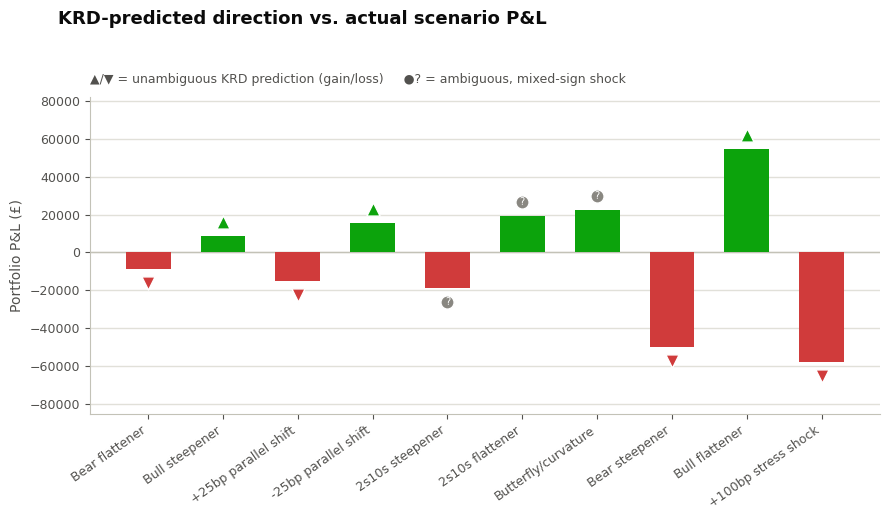

In [13]:
values = [scenario_pnl[name] for name in scenario_order]
bar_colors = [COLOR_GOOD if v >= 0 else COLOR_CRITICAL for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(scenario_order, values, color=bar_colors, width=0.6, zorder=3)
ax.axhline(0, color=COLOR_BASELINE, linewidth=1, zorder=2)

ymin, ymax = ax.get_ylim()
marker_offset = (ymax - ymin) * 0.06

for i, name in enumerate(scenario_order):
    v = scenario_pnl[name]
    predicted = predictions[name]
    y = v + marker_offset if v >= 0 else v - marker_offset
    if predicted == 1:
        ax.scatter(i, y, marker="^", s=90, color=COLOR_GOOD, edgecolor="white", linewidth=1, zorder=4)
    elif predicted == -1:
        ax.scatter(i, y, marker="v", s=90, color=COLOR_CRITICAL, edgecolor="white", linewidth=1, zorder=4)
    else:
        ax.scatter(i, y, marker="o", s=90, color=COLOR_MUTED, edgecolor="white", linewidth=1, zorder=4)
        ax.annotate("?", xy=(i, y), ha="center", va="center", fontsize=7, color="white", zorder=5)

ax.set_xticks(range(len(scenario_order)))
ax.set_xticklabels(scenario_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Portfolio P&L (\u00a3)", color=COLOR_SECONDARY, fontsize=10)
_style_axes(ax)

fig.suptitle("KRD-predicted direction vs. actual scenario P&L", x=0.07, y=1.03, ha="left",
             fontsize=13, fontweight="bold", color=COLOR_PRIMARY)
ax.set_title("\u25b2/\u25bc = unambiguous KRD prediction (gain/loss)     \u25cf? = ambiguous, mixed-sign shock",
             fontsize=9, color=COLOR_SECONDARY, loc="left", pad=10)

pad = (ymax - ymin) * 0.18
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

### Finding

7 of the 10 scenarios move every one of the 10 real pillars in the same
direction — the 3 pure parallel shifts, plus (checking the actual per-tenor
shocks, not just assuming) all 4 level+twist combos, since the ±30bp twist
never flips sign against the ±50bp/100bp level component. For all 7, the
net-DV01-based prediction matched the actual scenario P&L direction exactly
— **0 contradictions**.

The remaining 3 — 2s10s steepener, 2s10s flattener, Butterfly/curvature —
move tenors in opposite directions by construction, so KRD sign alone can't
call them, and they were deliberately left unpredicted rather than forced
into the framework. For what it's worth: 2s10s steepener actually lost
money (-£18,594.89) and 2s10s flattener gained (+£19,031.53), which lines
up with the 10Y point's overwhelmingly dominant KRD (+£680.79, more than 3x
every other tenor combined) rather than the 5Y point's negative KRD — a
naive "short the 5Y point" intuition would have guessed the wrong driver
here. This is exactly the honest limit the question anticipated: KRD's sign
pattern alone isn't sufficient for mixed-direction shocks; only the full
magnitude-weighted calculation resolves them.

## 11. Is the June→July residual (Section 5) typical, or was it a lucky/unlucky draw? How stable is the PC1-3 residual ratio across time?

Section 5 showed one specific one-month window (2025-06-02 → 2025-07-02) where
the top-3 PCs left an 11.6% residual — above the ~5% soft-check threshold
`attribute_pnl` warns on. Is that window unusual, or is a >5% residual actually
common? Sample ~15 evenly-spaced one-month windows across the full historical
archive (every 25th trading day, one month apart) and find out.

In [14]:
import warnings

dates_after_trade = [d for d in dates if date.fromisoformat(d) >= TRADE_DATE]
step = 25  # ~1 month of trading days
anchor_idx = list(range(0, len(dates_after_trade) - step, step))

stability_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in anchor_idx:
        d_a = date.fromisoformat(dates_after_trade[i])
        d_b = date.fromisoformat(dates_after_trade[i + step])
        c_a = _curve_for_date(d_a)
        c_b = _curve_for_date(d_b)
        r = attribute_pnl(portfolio, c_a, d_a, c_b, d_b, c_a.zero_rate(1.0), eigenvectors, tenors, n_components=3)
        ratio = abs(r['residual']) / abs(r['curve_factor_pnl'])
        stability_rows.append({"date_a": d_a, "date_b": d_b, "ratio": ratio})

stability_df = pd.DataFrame(stability_rows)
display(stability_df.style.format({"ratio": "{:.2%}"}))

n_exceed = (stability_df["ratio"] > 0.05).sum()
print(f"\n{n_exceed}/{len(stability_df)} windows ({n_exceed / len(stability_df):.0%}) exceed the 5% threshold")
print(f"median ratio: {stability_df['ratio'].median():.2%}")
print(f"mean ratio:   {stability_df['ratio'].mean():.2%}")
worst = stability_df.loc[stability_df['ratio'].idxmax()]
print(f"max ratio:    {worst['ratio']:.2%}  ({worst['date_a']} -> {worst['date_b']})")

,date_a,date_b,ratio
0,2025-01-02,2025-02-06,0.73%
1,2025-02-06,2025-03-13,1.93%
2,2025-03-13,2025-04-17,69.71%
3,2025-04-17,2025-05-28,1.14%
4,2025-05-28,2025-07-02,5.58%
5,2025-07-02,2025-08-06,5.03%
6,2025-08-06,2025-09-11,1.13%
7,2025-09-11,2025-10-16,2.47%
8,2025-10-16,2025-11-20,0.49%
9,2025-11-20,2025-12-29,6.02%



5/15 windows (33%) exceed the 5% threshold
median ratio: 1.14%
mean ratio:   13.37%
max ratio:    104.47%  (2026-02-03 -> 2026-03-10)


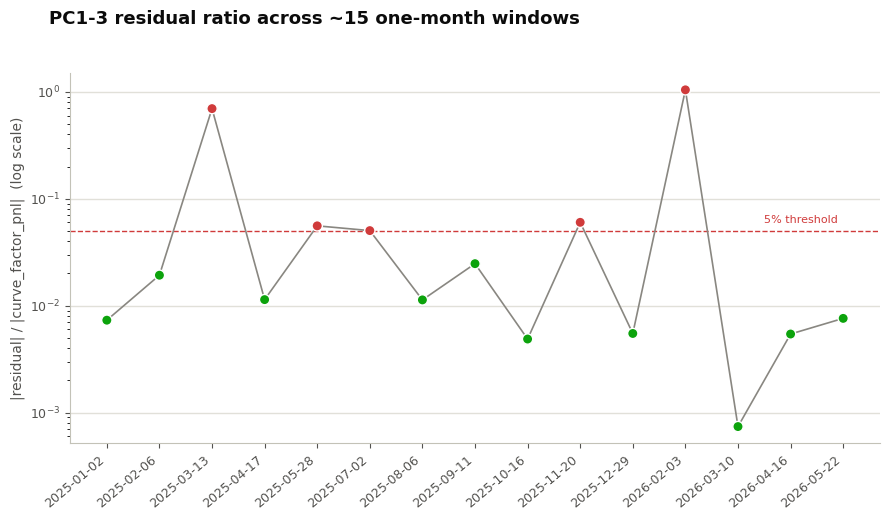

In [15]:
x = range(len(stability_df))
point_colors = [COLOR_CRITICAL if r > 0.05 else COLOR_GOOD for r in stability_df["ratio"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, stability_df["ratio"], color=COLOR_MUTED, linewidth=1.2, zorder=2)
ax.scatter(x, stability_df["ratio"], color=point_colors, s=55, zorder=3, edgecolor="white", linewidth=1)
ax.axhline(0.05, color=COLOR_CRITICAL, linewidth=1, linestyle="--", zorder=1)
ax.annotate("5% threshold", xy=(len(x) - 1, 0.05), xytext=(-4, 6), textcoords="offset points",
            ha="right", fontsize=8, color=COLOR_CRITICAL)

ax.set_yscale("log")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{a}" for a in stability_df["date_a"]], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("|residual| / |curve_factor_pnl|  (log scale)", color=COLOR_SECONDARY, fontsize=10)
_style_axes(ax)

fig.suptitle("PC1-3 residual ratio across ~15 one-month windows", x=0.06, y=1.03, ha="left",
             fontsize=13, fontweight="bold", color=COLOR_PRIMARY)

plt.tight_layout()
plt.show()

### Finding

5 of the 15 sampled one-month windows (**33%**) exceed the 5% residual
threshold — meaningfully more common than an "edge case" framing would
suggest. The median ratio is a reassuring **1.14%** (most months, PC1-3
genuinely capture almost everything), but the distribution has a fat right
tail: the mean (**13.37%**) is dragged far above the median by two dramatic
outliers — **2026-02-03 → 2026-03-10 at 104.47%** (the residual actually
*exceeds* `curve_factor_pnl` in magnitude) and **2025-03-13 → 2025-04-17 at
69.71%**.

Section 5's 11.6% figure sits on the *low* end of the 5 breaching windows —
higher than three windows that only just cross 5% (~5.0-6.0%), but nowhere
near the two extreme outliers. So the June→July example wasn't cherry-picked
to look bad, but it also wasn't the worst case in this sample by a wide
margin. The honest takeaway: a >5% residual isn't rare for this portfolio —
it happens roughly 1 month in 3 in this sample — so `curve_factor_pnl` at a
fixed `n_components` should be read as a useful approximation, not a number
to trust blindly window over window.